In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/MLkurs") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

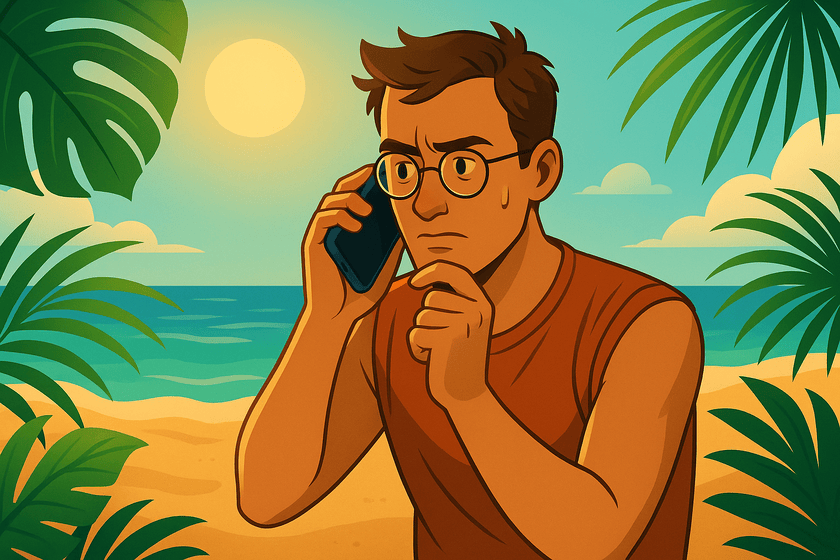

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


brudnopis komentarzowy for updates for me:
survived obv istotne
pclass - istotne ale jeszcze nie uwzglednione
name - wyciagniety tytul, samo name do usuniecia imo
sex - istotne
age - istotne
sibsp, parch - podliczone polaczone jako family reszta kosz
ticket - chyba niepotrzebne do analizy bo nie ma info od czego zalezy numer biletu, czy to randomowe czy w zaleznosci do czegos jest jakis numer
fare - mozliwe istotne prawdopodobnie
cabin - moze bardziej jako deck niz jako samo cabin ale zmienione jako czy jest info o kabinie czy nie wiec cabin do wywalenia
embarked - mozna sprawdzic czy wplywa to na deck na ktorym byl pasazer ale idk tbc later

In [ ]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [ ]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


tu jest normalize=True bo inaczej pododawalo by wszystkie jedynki a tak to sa to proporcje wobec drugiejliczby

61,61% pasazerow nie przezylo; 38,38% przezylo
jest to nierównomiernie rozłożona klasa, roznica jednak nie jest bardzo duza. wiekszosc pasazerow uwzglednionych w plikach do analizy znajduje sie w klasie 0 - nie przezyli.

In [ ]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [ ]:
titanic_df.shape #sprawdzam liczbe wierszy i kolumn w pliku

(891, 11)

In [ ]:
titanic_df.columns #a tutaj nazwy kolumn sprawdzam zeby double check the gotten info

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


na ten moment mysle ze:
info, ktore moze miec wplyw na to czy przezyli czy nie: Pclass, sex, age, sibsp i parch - moze na tej podstawie jakos podsumowac w ile osob podrozowala osoba?, cabin - wziac z niej miejsce na statku?,

brakuje sporo age, fare i cabin

In [ ]:
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


tu widac ze przy name sa tez mr miss itp - mozna wywnioskowac status tej osoby

moje wybrane wartosci do dodania to - policzenie family size i czy podrozowala sama ta osoba na tej bazie oraz chcialabym wydobyc tytuly z imion oraz sprawdzic czy wiadomo w jakiej kabinie jest czy nie

In [ ]:
titanic_df['Name'].str.extract(r',\s(.*)\.')  #r przerabia na raw string, znajduje co jest miedzy przecinkiem ze spacja i kropka i wypisuje

,0
PassengerId,
1,Mr
2,Mrs
3,Miss
4,Mrs
5,Mr
...,...
887,Rev
888,Miss
889,Miss


tu udalo mi sie wyciagnac to o czym pisalam wczesniej

In [ ]:
rodzina=titanic_df['SibSp']+titanic_df['Parch']
print(rodzina)

PassengerId
1      1
2      1
3      0
4      1
5      0
      ..
887    0
888    0
889    3
890    0
891    0
Length: 891, dtype: int64


tu policzylam ile osob jest z ta konkretna osoba, teraz chce zrobic po prostu czy byla sama czy *nie*

In [ ]:
titanic_df['Famsize']=rodzina
titanic_df['Alone']=(titanic_df['Famsize']==0).astype(int) #jesli alone jest 1 tzn true czyli sama podrozuje!
print(titanic_df['Alone'])

PassengerId
1      0
2      0
3      1
4      0
5      1
      ..
887    1
888    1
889    0
890    1
891    1
Name: Alone, Length: 891, dtype: int64


In [ ]:
titanic_df.isna().sum() # isna sprawdza czy sa brakujace wartosci gdzie a jak dodam sum to wtedy sumuje ile we wszystkich rekordach brakuje tych wartosci

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98
Cabin,687


mega duzo brakuje informacji o cabin, potem wiek i potem fare. zajme sie najpierw cabin - dodam zmienna ktora bedzie informacja czy mamy info o kabinie czy nie mamy

In [ ]:
titanic_df['CabinKnown']=(titanic_df['Cabin']=='NaN').astype(int)
print(titanic_df['CabinKnown'])

PassengerId
1      0
2      0
3      0
4      0
5      0
      ..
887    0
888    0
889    0
890    0
891    0
Name: CabinKnown, Length: 891, dtype: int64


jesli jest 0 to nie znamy kabiny

teraz zajmuje sie wiekiem; najpierw sprawdzam jak to sie prezentuje na wykresie

<Axes: >

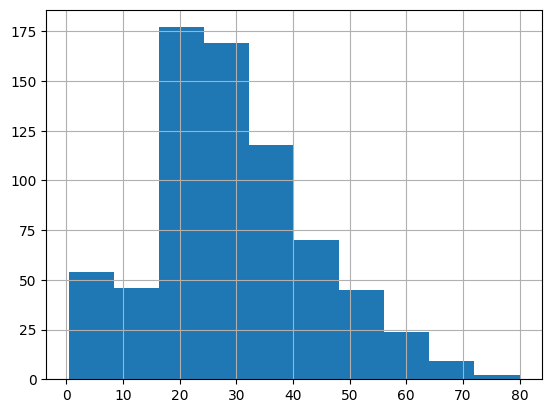

In [ ]:
titanic_df['Age'].hist()

In [ ]:
titanic_df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


patrzac na histogram najwiecej jest osob pomiedzy +/-17 a 40 lat, pozniej ilosc osob jest znaczaco mniejsza. rozklad ten nie jest symetryczny. ma ogon po prawej stronie i najwieksza wartosc to 80 lat
srednia (mean) to 29,699 lat a medieana (50%) to 28
do uzupelnienia pustych pol uzyje mediany, bo wydaje mi sie, ze na nia mniej wplynely te wartosci wieksze (czyli starsze osoby) ktorych jest mniej. however, i mediana i srednia arytmetyczna maja podobne wartosci wiec rownoczesnie wydaje mi sie, ze gdybym uzyla sredniej to tez nie prowadziloby to do potencjalnych problemow w pozniejszej analizie

In [ ]:
titanic_df['Age']=titanic_df['Age'].fillna(titanic_df['Age'].median()) # tu wlasnie podmienilam NaN na wartosc mediany

,Fare
count,793.000000
mean,33.123938
std,51.578312
min,0.000000
25%,7.925000
50%,14.500000
75%,31.275000
max,512.329200


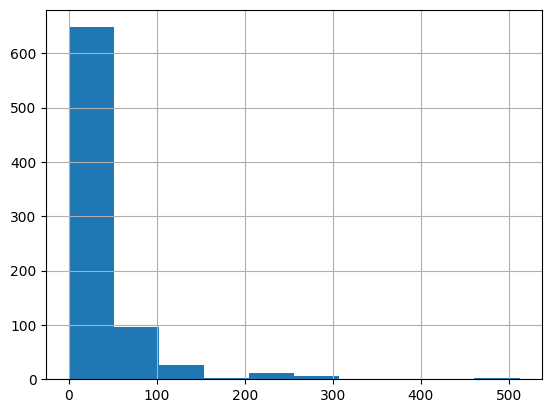

In [ ]:
titanic_df['Fare'].hist()
titanic_df['Fare'].describe()

w tym przypadku w ogole jest duzy rozstrzal - najmniejsza cena biletu to 0, najwieksza 512 - wydaje mi sie, ze to niekoniecznie jest blad. jest szansa ze ktos kupil mega mega drogi bilet. jednak, nadal brakuje wielu wartosci. patrzac na histogram widzimy asymetrie rozkladu. znow chce uzyc mediany a nie sredniej przez mniejszy wplyw wartosci skrajnych, ktore w tym przypadku znacznie roznia sie od tych, ktore wystepuja najczesciej. zastapie wiec NaN wartoscia  mediany czyli 14,5

In [ ]:
titanic_df['Fare']=titanic_df['Fare'].fillna(titanic_df['Fare'].median()) # tu wlasnie podmienilam NaN na wartosc mediany

In [ ]:
titanic_df.columns #update kolumn wypisane

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked', 'Famsize', 'Alone', 'CabinKnown'],
      dtype='object')

In [ ]:
titanic_df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


tu najwiecej osob wsiadlo na stacji S, wiec do tych rekordow, ktore nie maja tej wartosci dopisze wartosc S, ze wzgledu na wieksze prawdopodobienstwo patrzac na ilosc osob na kazdej stacji

In [ ]:
titanic_df['Embarked'].value_counts(normalize=True)*100 #zanim zmienie upewniam sie patrzac na procenty

,proportion
Embarked,
S,72.440945
C,18.897638
Q,8.661417


In [ ]:
titanic_df['Embarked']=titanic_df['Embarked'].fillna('S')

In [ ]:
titanic_df['Embarked'].isna().sum()

np.int64(0)

In [ ]:
titanic_df=titanic_df.drop(columns=['SibSp','Parch','Ticket','Cabin'])

In [ ]:
titanic_df['Title'] = titanic_df['Name'].str.extract(r',\s*(.*?)\.')[0]

In [ ]:
print(titanic_df.columns.tolist())

['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Fare', 'Embarked', 'Famsize', 'Alone', 'CabinKnown', 'Title']


teraz usunelam te, ktorych nie bede analizowac zeby nie zasmiecac. musze tez zmienic sex i embarked tak, zeby latwo bylo to czytac i analizowac

In [ ]:
titanic_df['Sex']=titanic_df['Sex'].map({'male':0,'female':1})

teraz robie one-hot encoding ale recznie bo chce sie nauczyc bo nie robilam tego wczesniejxd

In [ ]:
titanic_df['Embarked_C']=(titanic_df['Embarked']=='C').astype(int)
titanic_df['Embarked_S']=(titanic_df['Embarked']=='S').astype(int)
titanic_df['Embarked_Q']=(titanic_df['Embarked']=='Q').astype(int)


In [ ]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Name        891 non-null    object 
 3   Sex         891 non-null    int64  
 4   Age         891 non-null    float64
 5   Fare        891 non-null    float64
 6   Embarked    891 non-null    object 
 7   Famsize     891 non-null    int64  
 8   Alone       891 non-null    int64  
 9   CabinKnown  891 non-null    int64  
 10  Title       891 non-null    object 
 11  Embarked_C  891 non-null    int64  
 12  Embarked_S  891 non-null    int64  
 13  Embarked_Q  891 non-null    int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 104.4+ KB


fun fact, wczesniej robilam po prostu titanic_df.fill na zamiast titanic_df=titanic_df.fillna i mi nie dzialalo i nie wiedzialam czemuxd

In [ ]:
titanic_df=titanic_df.drop(columns=['Embarked'])

In [ ]:
titanic_df.isna().sum() #sprawdzam i udalo sie zamienic wszystko i usunac to co chcialam

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
Fare,0
Famsize,0
Alone,0
CabinKnown,0
Title,0


teraz eda

In [ ]:
titanic_df.describe()

,Survived,Pclass,Sex,Age,Fare,Famsize,Alone,CabinKnown,Embarked_C,Embarked_S,Embarked_Q
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.0,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,31.075514,0.904602,0.602694,0.0,0.188552,0.725028,0.086420
std,0.486592,0.836071,0.477990,13.019697,49.003875,1.613459,0.489615,0.0,0.391372,0.446751,0.281141
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,8.050000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,0.000000,3.000000,0.000000,28.000000,14.500000,0.000000,1.000000,0.0,0.000000,1.000000,0.000000
75%,1.000000,3.000000,1.000000,35.000000,29.125000,1.000000,1.000000,0.0,0.000000,1.000000,0.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200,10.000000,1.000000,0.0,1.000000,1.000000,1.000000


In [ ]:
titanic_df['CabinKnown'].value_counts()

,count
CabinKnown,
0,891


tu jednak widze ze cos nie tak poszlo ze sprawdzeniem mi czy jest przypisana kabina czy nie, juz usunelam kolumne cabin wiec musze ejszcze raz zaladowac i wyciagnac cabinknown jeszcze raz

In [ ]:
again_df=pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [ ]:
again_df['CabinKnown']=again_df['Cabin'].notna().astype(int)

In [ ]:
again_df['CabinKnown'].value_counts()

,count
CabinKnown,
0,687
1,204


In [ ]:
titanic_df['CabinKnown']=again_df['CabinKnown']

In [ ]:
titanic_df['CabinKnown'].value_counts()

,count
CabinKnown,
0,687
1,204


In [ ]:
titanic_df.describe()

,Survived,Pclass,Sex,Age,Fare,Famsize,Alone,CabinKnown,Embarked_C,Embarked_S,Embarked_Q
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,31.075514,0.904602,0.602694,0.228956,0.188552,0.725028,0.086420
std,0.486592,0.836071,0.477990,13.019697,49.003875,1.613459,0.489615,0.420397,0.391372,0.446751,0.281141
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,8.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,0.000000,28.000000,14.500000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,3.000000,1.000000,35.000000,29.125000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='Survived', ylabel='count'>

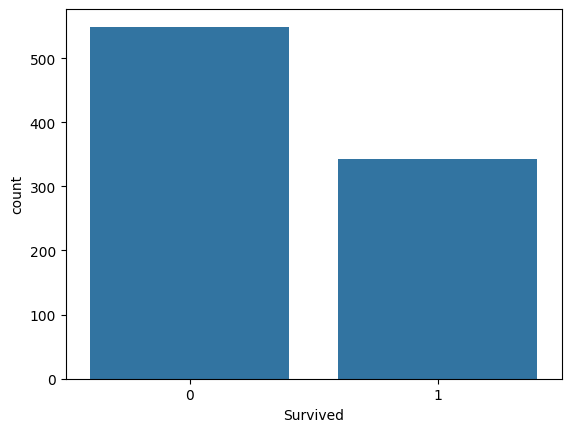

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=titanic_df, x='Survived')

to nam pokazuje na wykresie ile osob przezylo a ile niestety nie - jak wiemy z poczatkowych analiz, okolo 62% zginelo, co jest poprawnie odzwierciedlone na wykresie

<Axes: xlabel='Pclass', ylabel='count'>

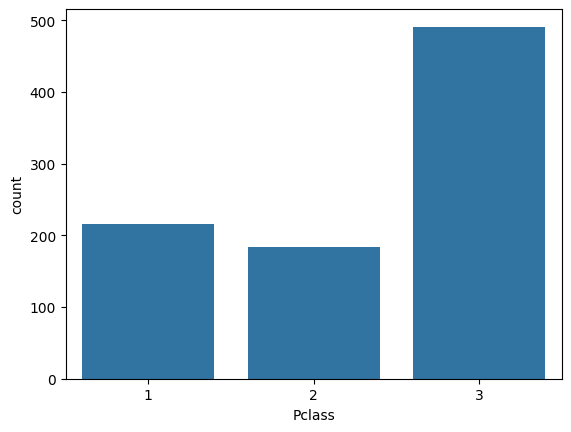

In [ ]:
sns.countplot(data=titanic_df, x='Pclass')

tu jest pokzane ile osob bylo z jakiej klasy

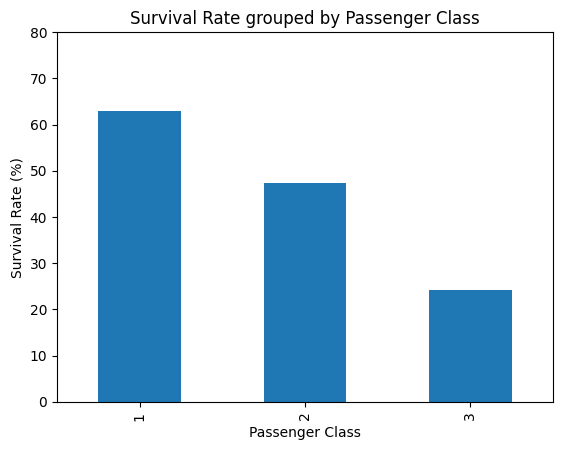

In [ ]:
survival=titanic_df.groupby('Pclass')['Survived'].mean()*100
survival.plot(kind='bar')

plt.title('Survival Rate grouped by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 80)
plt.show()

jak mozna bylo sie spodziewac, najwiekszy procent przezycia jest dla klasy 1 gzdie ponad 60% osob przezylo. tendecja ta jest malejaca kolejno dla 2 i 3 klasy

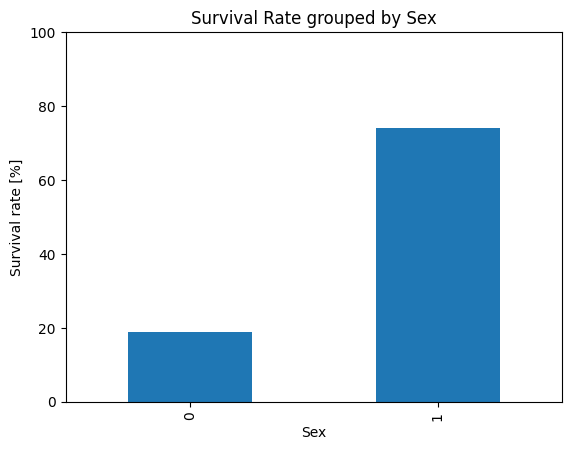

In [ ]:
survival_by_sex=titanic_df.groupby('Sex')['Survived'].mean()*100
survival_by_sex.plot(kind='bar')
plt.title('Survival Rate grouped by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival rate [%]')
plt.ylim(0,100)
plt.show()

jak widac, mniej niz 20% mezczyzn obecnych na pokladzie przezylo. wiekszosc survivors stanowia kobiety, z prawie 80%

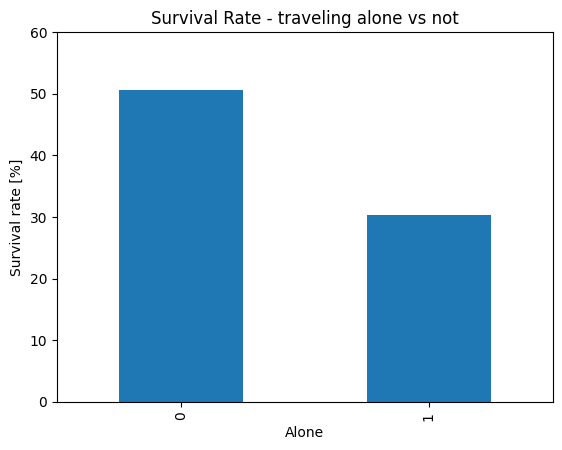

In [ ]:
survival=titanic_df.groupby('Alone')['Survived'].mean()*100
survival.plot(kind='bar')
plt.title('Survival Rate - traveling alone vs not')
plt.ylabel('Survival rate [%]')
plt.ylim(0,60)
plt.show()

wiemy, ze wartosc 0 oznacza, ze pasazer podrozowal z kims. co ciekawe, wiecej osob z "grupy" 0 (podroz z kims) przezylo w porownaniu do tych, co podrozowali samotnie

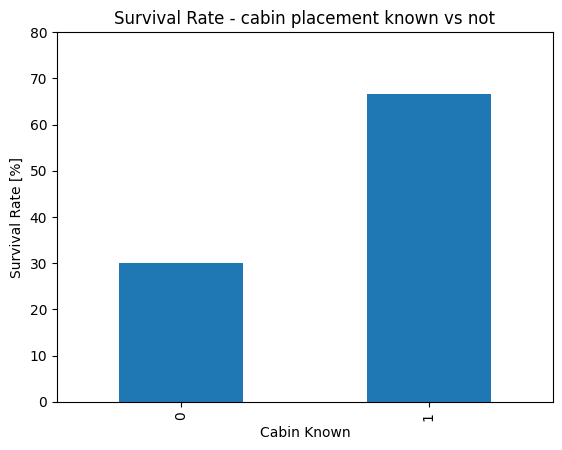

In [ ]:
survival_cabinknown=titanic_df.groupby('CabinKnown')['Survived'].mean()*100
survival_cabinknown.plot(kind='bar')
plt.title('Survival Rate - cabin placement known vs not')
plt.xlabel('Cabin Known')
plt.ylabel('Survival Rate [%]')
plt.ylim(0,80)
plt.show()

jak widac, porownujac osoby, ktorych kabina przypisana byla wiadoma do tych, ktorych nie bylo tej informacji - wieksza zywotnosc maja te, ktorych numer kabiny jest wiadoma.

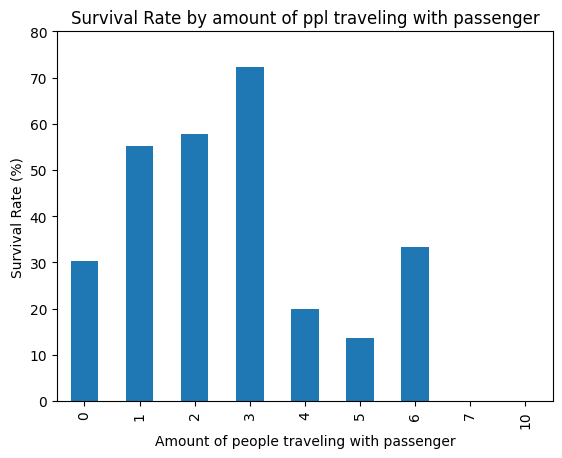

In [ ]:
survival_rate = titanic_df.groupby('Famsize')['Survived'].mean() * 100

survival_rate.plot(kind='bar')

plt.title('Survival Rate by amount of ppl traveling with passenger')
plt.xlabel('Amount of people traveling with passenger')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 80)
plt.show()

najwieksza procentowa survival rate mialy osoby, ktore podrozowalt z 3 innymi osobami. Nastepnie kolejno z 2 i 1. najmniejszy wspolczynnik przezycia mialy osoby podrozujace z piecioma innymi osobami.

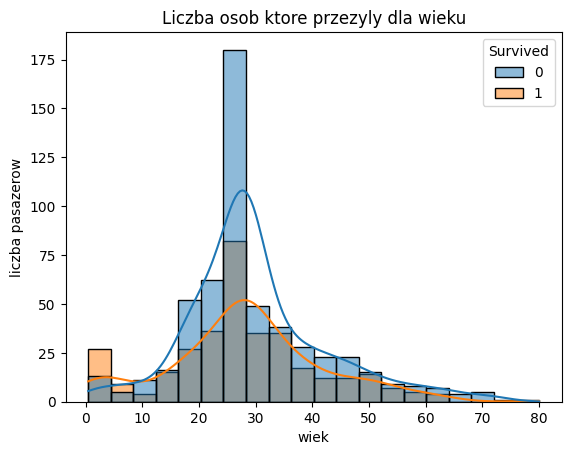

In [ ]:
sns.histplot(
    data=titanic_df,
    x='Age',
    hue='Survived',
    bins=20,
    kde=True #to aproksymacja
)

plt.title('Liczba osob ktore przezyly dla wieku')
plt.xlabel('wiek')
plt.ylabel('liczba pasazerow')
plt.show()

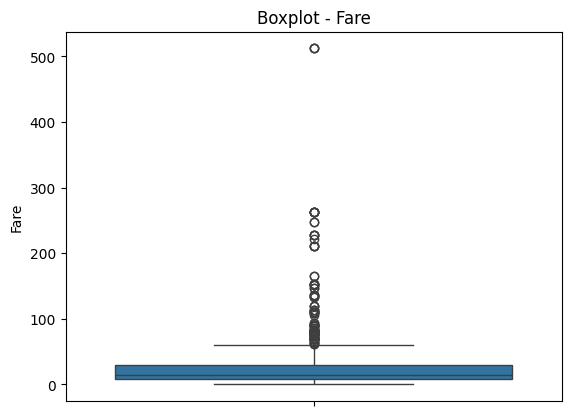

In [ ]:
sns.boxplot(data=titanic_df, y='Fare')
plt.title('Boxplot - Fare')
plt.ylabel('Fare')
plt.show()

patrzac na ten boxplot, widac outlinery - jest ich sporo ale najdalszy to ta fare za ponad 500

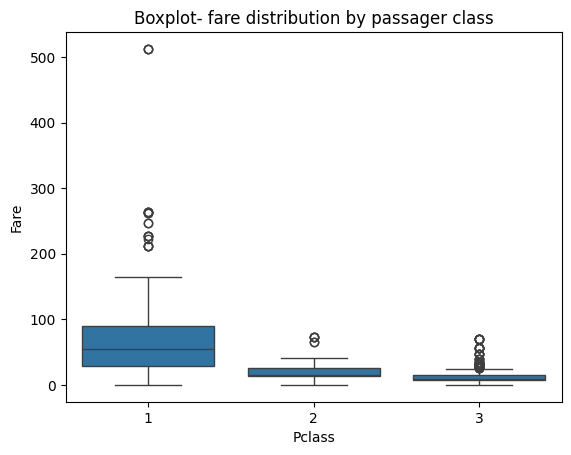

In [ ]:
sns.boxplot(data=titanic_df, x='Pclass', y='Fare')
plt.title("Boxplot- fare distribution by passager class")
plt.show()

analizujac oba boxploty widac, ze wartosci ktore sa odstajace w zmiennej fare prawdopodobnie sa zwiazane z typem biletu, ktory byl zakupiony.widac, ze outlinery z najwieksza roznica od wartosci sredniej i mediany wystepuja dla pierwszej klasy. outlinery nie zostaly usuniete ani uznane za bledne bo mozliwe jest, ze ktos zaplacil wiecej za bilet.

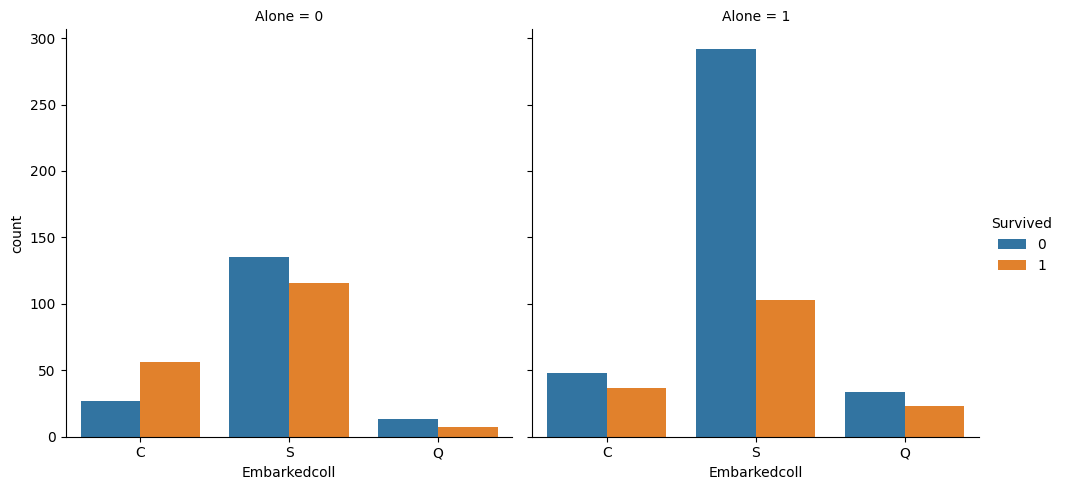

In [ ]:
titanic_df['Embarkedcoll']=titanic_df[['Embarked_C','Embarked_S','Embarked_Q']].idxmax(axis=1).str.replace('Embarked_','')
sns.catplot(data=titanic_df,x='Embarkedcoll',hue='Survived',col='Alone',kind='count',order=['C','S','Q'])


In [ ]:
titanic_df.to_csv('titanic_zadanie1.csv')
import os
os.listdir()

['.config', 'drive', 'titanic_zadanie1.csv', 'sample_data']

In [ ]:
titanic_df.to_csv('/content/drive/MyDrive/MLkurs/titanic_zadanie1.csv', index=False)